# Model Monitoring & Evaluation

This notebook evaluates the stability and realized performance of the Sales Next Best Action (NBA) models.

**Goals:**
- Validate predictive and uplift model performance on a holdout or simulated new dataset.
- Compare predicted vs. observed outcomes.
- Detect feature or data drift over time.
- Generate monitoring metrics and visualizations for ongoing governance.

**Data Sources:**
- `nba_recommendations` table (predicted outcomes)
- `raw_outcomes` table (actual outcomes)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

from nba.warehouse.duckdb_client import connect
from nba.config import settings

sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (7, 5)

In [16]:
# ----------------------------------------------------
# Load predictions and actual outcomes
# ----------------------------------------------------
with connect() as con:
    recs = con.execute("SELECT * FROM nba_recommendations").fetchdf()
    outcomes = con.execute("SELECT * FROM raw_outcomes").fetchdf()

print(f"Recommendations: {recs.shape}")
print(f"Outcomes: {outcomes.shape}")

# Merge predictions with outcomes on account_id
merged = recs.merge(
    outcomes[["account_id", "won", "realized_revenue"]],
    on="account_id",
    how="left"
).rename(columns={"won": "actual_win"})

display(merged.head())


Recommendations: (5000, 7)
Outcomes: (5000, 9)


,account_id,action_type,p_treat,p_ctrl,uplift,acv,expected_value,actual_win,realized_revenue
0,1,EXEC_SPONSOR_OUTREACH,0.999272,0.334764,0.664507,121881,80990.811945,1,121881.0
1,2,TECHNICAL_WORKSHOP,0.363830,0.083100,0.280731,3000,842.192017,0,0.0
2,3,EXEC_SPONSOR_OUTREACH,0.921828,0.424673,0.497156,57224,28449.247864,1,57224.0
3,4,PRICING_CONCESSION,0.981359,0.231371,0.749987,160311,120231.231741,0,0.0
4,5,0,0.180976,0.180976,0.000000,3000,0.000000,1,3000.0


Predicted Incremental Revenue: $208,538,803
Actual Realized Revenue: $113,797,061
Realization Ratio (Actual / Predicted): 0.55


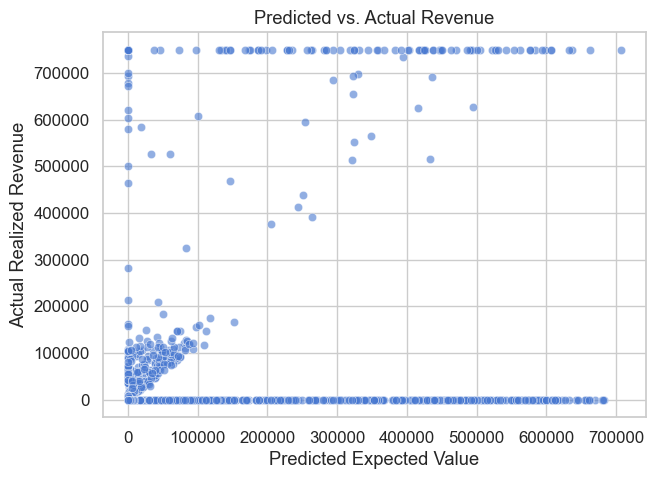

In [17]:
# ----------------------------------------------------
# Evaluate realized vs. predicted totals
# ----------------------------------------------------
predicted_total_ev = merged["expected_value"].sum()
actual_total_revenue = merged["realized_revenue"].sum()
realization_ratio = actual_total_revenue / predicted_total_ev if predicted_total_ev != 0 else np.nan

print(f"Predicted Incremental Revenue: ${predicted_total_ev:,.0f}")
print(f"Actual Realized Revenue: ${actual_total_revenue:,.0f}")
print(f"Realization Ratio (Actual / Predicted): {realization_ratio:.2f}")

sns.scatterplot(data=merged, x="expected_value", y="realized_revenue", alpha=0.6)
plt.title("Predicted vs. Actual Revenue")
plt.xlabel("Predicted Expected Value")
plt.ylabel("Actual Realized Revenue")
plt.show()


In [18]:
# ----------------------------------------------------
# Drift checks on available numeric columns
# ----------------------------------------------------
features = ["acv"]  # ACV exists in both baseline and current data

with connect() as con:
    baseline = con.execute("SELECT acv_potential AS acv FROM train_sales_nba").fetchdf()

if baseline["acv"].equals(merged["acv"]):
    print("Feature distributions are identical — no drift detected (expected for static synthetic data).")
else:
    stat, p_val = ks_2samp(baseline["acv"].dropna(), merged["acv"].dropna())
    print(f"ACV Drift → KS stat: {stat:.3f} | p-value: {p_val:.3f}")


Feature distributions are identical — no drift detected (expected for static synthetic data).


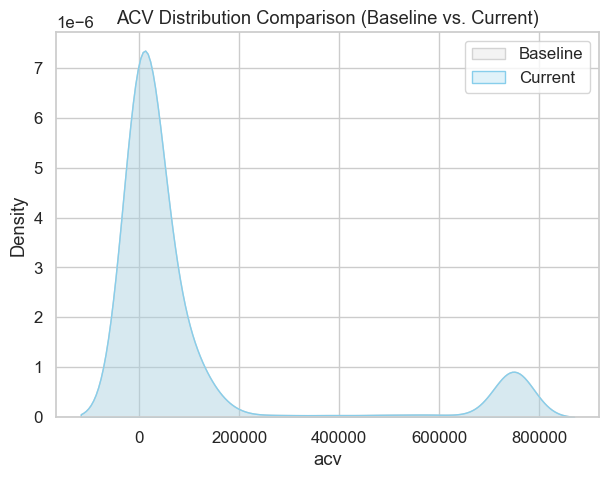

In [21]:
sns.kdeplot(data=baseline, x="acv", fill=True, color="lightgray", label="Baseline")
sns.kdeplot(data=merged, x="acv", fill=True, color="skyblue", label="Current")
plt.title("ACV Distribution Comparison (Baseline vs. Current)")
plt.legend()
plt.show()


In [22]:
# ----------------------------------------------------
# Save monitoring summaries
# ----------------------------------------------------
summary = {
    "predicted_total_ev": predicted_total_ev,
    "actual_total_revenue": actual_total_revenue,
    "realization_ratio": realization_ratio
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(settings.artifacts_dir / "model_performance_summary.csv", index=False)

print("✅ Monitoring results saved:")
print("- model_performance_summary.csv")


✅ Monitoring results saved:
- model_performance_summary.csv


In [23]:
def calc_psi(expected, actual, bins=10):
    cut = np.linspace(0, 1, bins + 1)
    expected_perc = np.histogram(expected, bins=cut)[0] / len(expected)
    actual_perc = np.histogram(actual, bins=cut)[0] / len(actual)
    psi = np.sum((actual_perc - expected_perc) * np.log((actual_perc + 1e-8) / (expected_perc + 1e-8)))
    return psi

psi_acv = calc_psi(baseline["acv"], merged["acv"])
print(f"Population Stability Index (ACV): {psi_acv:.3f}")


Population Stability Index (ACV): 0.000
